# Based on the fink-tutorial "Fink case study: ELASTiCC data"

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('talk')

## Load data

Let's assume you downloaded data from the Fink Data Transfer service. You can read the data using pandas:

In [2]:
# pdf = pd.read_parquet('ftransfer_elasticc_2023-02-08_902820/')
# pdf = pd.read_parquet('ftransfer_elasticc_2023-02-03_177123_merged.parquet')
import pyarrow.parquet as pq
parquet_file = pq.ParquetFile('ftransfer_elasticc_2023-02-03_177123_merged.parquet')

i = 0
n = 3
for batch in parquet_file.iter_batches():
    print("RecordBatch")
    batch_df = batch.to_pandas()
    print("batch_df head:", batch_df.head())
    i = i+1
    if i==3:
        break

RecordBatch
batch_df head:         alertId                                          diaSource  \
0  251737256011  {'ccdVisitId': -1, 'decl': -61.90379549459633,...   
1  251737256012  {'ccdVisitId': -1, 'decl': -61.90379549459633,...   
0   51748442001  {'ccdVisitId': -1, 'decl': -3.3561699825034954...   
1  270801534009  {'ccdVisitId': -1, 'decl': -31.809784344737984...   
2  270801534011  {'ccdVisitId': -1, 'decl': -31.809784344737984...   

                                       prvDiaSources  \
0  [{'ccdVisitId': -1, 'decl': -61.90379549459633...   
1  [{'ccdVisitId': -1, 'decl': -61.90379549459633...   
0                                                 []   
1  [{'ccdVisitId': -1, 'decl': -31.80978434473798...   
2  [{'ccdVisitId': -1, 'decl': -31.80978434473798...   

                                 prvDiaForcedSources prvDiaNondetectionLimits  \
0  [{'ccdVisitId': 7496435467761565831, 'diaForce...                     None   
1  [{'ccdVisitId': 7496435467761565831, 'diaForce... 

In [3]:
# In case we have one big file, need to use an iterator
from pyarrow.parquet import ParquetFile
import pyarrow as pa 

pf = ParquetFile('ftransfer_elasticc_2023-02-03_177123_merged.parquet') 
first_ten_rows = next(pf.iter_batches(batch_size = 10000)) 
pdf = pa.Table.from_batches([first_ten_rows]).to_pandas() 

In [4]:
pdf.head(5)

,alertId,diaSource,prvDiaSources,prvDiaForcedSources,prvDiaNondetectionLimits,diaObject,cutoutDifference,cutoutTemplate,brokerIngestTimestamp,timestamp,...,PEAKMAG_z,PEAKMAG_Y,SNRMAX,SNRMAX2,SNRMAX3,NOBS,NOBS_SATURATE,year,month,day
0,251737256011,"{'ccdVisitId': -1, 'decl': -61.90379549459633,...","[{'ccdVisitId': -1, 'decl': -61.90379549459633...","[{'ccdVisitId': 7496435467761565831, 'diaForce...",None,"{'decl': -61.90379549459633, 'diaObjectId': 12...",None,None,2022-09-29 21:04:01.734883+00:00,2023-12-09 05:46:42.24,...,22.2416,22.4040,39.76480,21.33080,15.76890,160,0,2023,12,9
1,251737256012,"{'ccdVisitId': -1, 'decl': -61.90379549459633,...","[{'ccdVisitId': -1, 'decl': -61.90379549459633...","[{'ccdVisitId': 7496435467761565831, 'diaForce...",None,"{'decl': -61.90379549459633, 'diaObjectId': 12...",None,None,2022-10-14 02:07:11.223451+00:00,2023-12-09 06:20:58.56,...,22.2416,22.4040,39.76480,21.33080,15.76890,160,0,2023,12,9
0,51748442001,"{'ccdVisitId': -1, 'decl': -3.3561699825034954...",[],None,None,"{'decl': -3.3561699825034954, 'diaObjectId': 2...",None,None,2022-09-29 22:31:01.281208+00:00,2023-12-18 02:13:35.04,...,24.3243,24.4485,3.41271,2.97427,2.58639,257,0,2023,12,18
1,270801534009,"{'ccdVisitId': -1, 'decl': -31.809784344737984...","[{'ccdVisitId': -1, 'decl': -31.80978434473798...","[{'ccdVisitId': 2182565439289447772, 'diaForce...",None,"{'decl': -31.809784344737984, 'diaObjectId': 1...",None,None,2022-10-12 03:02:03.905409+00:00,2023-12-16 02:41:39.84,...,22.4025,22.5897,51.29360,33.13860,21.95900,206,0,2023,12,16
2,270801534011,"{'ccdVisitId': -1, 'decl': -31.809784344737984...","[{'ccdVisitId': -1, 'decl': -31.80978434473798...","[{'ccdVisitId': 2182565439289447772, 'diaForce...",None,"{'decl': -31.809784344737984, 'diaObjectId': 1...",None,None,2022-09-29 22:10:11.279842+00:00,2023-12-16 03:26:18.24,...,22.4025,22.5897,51.29360,33.13860,21.95900,206,0,2023,12,16


In [5]:
pdf[pdf['alertId']==270801534011]['diaObject'].values

array([{'decl': -31.809784344737984, 'diaObjectId': 135400767, 'hostgal2_dec': -999.0, 'hostgal2_ellipticity': -9999.0, 'hostgal2_mag_Y': 999.0, 'hostgal2_mag_g': 999.0, 'hostgal2_mag_i': 999.0, 'hostgal2_mag_r': 999.0, 'hostgal2_mag_u': 999.0, 'hostgal2_mag_z': 999.0, 'hostgal2_magerr_Y': 999.0, 'hostgal2_magerr_g': 999.0, 'hostgal2_magerr_i': 999.0, 'hostgal2_magerr_r': 999.0, 'hostgal2_magerr_u': 999.0, 'hostgal2_magerr_z': 999.0, 'hostgal2_ra': -999.0, 'hostgal2_snsep': -9.0, 'hostgal2_sqradius': -9999.0, 'hostgal2_zphot': -999.0, 'hostgal2_zphot_err': -999.0, 'hostgal2_zphot_p50': None, 'hostgal2_zphot_q000': -9.0, 'hostgal2_zphot_q010': -9.0, 'hostgal2_zphot_q020': -9.0, 'hostgal2_zphot_q030': -9.0, 'hostgal2_zphot_q040': -9.0, 'hostgal2_zphot_q050': -9.0, 'hostgal2_zphot_q060': -9.0, 'hostgal2_zphot_q070': -9.0, 'hostgal2_zphot_q080': -9.0, 'hostgal2_zphot_q090': -9.0, 'hostgal2_zphot_q100': -9.0, 'hostgal2_zspec': -999.0, 'hostgal2_zspec_err': -999.0, 'hostgal_dec': -31.8097381

In [6]:
print(pdf.keys())

Index(['alertId', 'diaSource', 'prvDiaSources', 'prvDiaForcedSources',
       'prvDiaNondetectionLimits', 'diaObject', 'cutoutDifference',
       'cutoutTemplate', 'brokerIngestTimestamp', 'timestamp',
       'rf_snia_vs_nonia', 'snn_snia_vs_nonia', 'snn_broad_class',
       'snn_broad_max_prob', 'cats_broad_class', 'cats_broad_max_prob',
       'cats_fine_class', 'cats_fine_max_prob', 'rf_agn_vs_nonagn',
       't2_broad_class', 't2_broad_max_prob', 'fink_broker_version',
       'fink_science_version', 'publisher', 'SNID', 'LIBID',
       'SIM_SEARCHEFF_MASK', 'GENTYPE', 'SIM_TEMPLATE_INDEX', 'ZCMB', 'ZHELIO',
       'ZCMB_SMEAR', 'RA', 'DEC', 'MWEBV', 'GALNMATCH', 'GALID', 'GALZPHOT',
       'GALZPHOTERR', 'GALSNSEP', 'GALSNDDLR', 'RV', 'AV', 'MU', 'LENSDMU',
       'PEAKMJD', 'MJD_DETECT_FIRST', 'MJD_DETECT_LAST', 'DTSEASON_PEAK',
       'PEAKMAG_u', 'PEAKMAG_g', 'PEAKMAG_r', 'PEAKMAG_i', 'PEAKMAG_z',
       'PEAKMAG_Y', 'SNRMAX', 'SNRMAX2', 'SNRMAX3', 'NOBS', 'NOBS_SATURATE',
     

<AxesSubplot: >

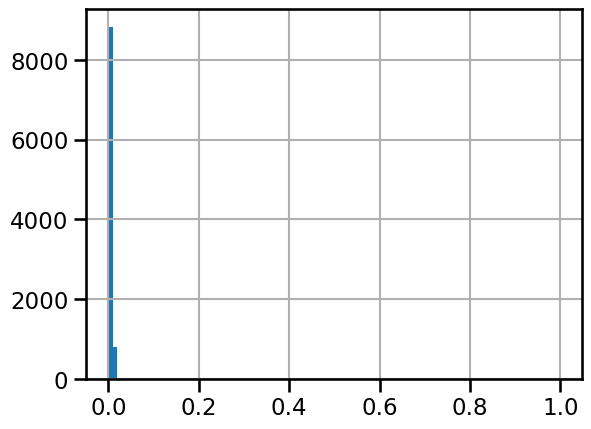

In [7]:
pdf['snn_snia_vs_nonia'].hist(bins=100)

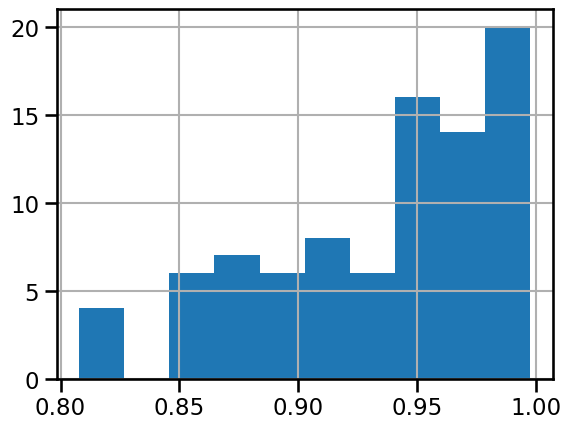

In [8]:
# Watch out - overwrites pdf with a subselection of it
pdfnsn = pdf[pdf['snn_snia_vs_nonia']>0.8]
pdfnsn['snn_snia_vs_nonia'].hist(bins=10)
pdf = pdfnsn

## Reconstruct alert light-curves

In [9]:
def extract_history(history_list: list, field: str) -> list:
    """Extract the historical measurements contained in the alerts
    for the parameter `field`.

    Parameters
    ----------
    history_list: list of dict
        List of dictionary from alert[history].
    field: str
        The field name for which you want to extract the data. It must be
        a key of elements of history_list
    
    Returns
    ----------
    measurement: list
        List of all the `field` measurements contained in the alerts.
    """
    if history_list is None:
        return []
    try:
        measurement = [obs[field] for obs in history_list]
    except KeyError:
        print('{} not in history data'.format(field))
        measurement = []

    return measurement

def extract_field(alert: dict, category: str, field: str) -> np.array:
    """ Concatenate current and historical observation data for a given field.
    
    Parameters
    ----------
    alert: dict
        Dictionnary containing alert data
    category: str
        prvDiaSources or prvDiaForcedSources
    field: str
        Name of the field to extract.
    
    Returns
    ----------
    data: np.array
        List containing previous measurements and current measurement at the
        end. If `field` is not in the category, data will be
        [alert['diaSource'][field]].
    """
    data = np.concatenate(
        [
            [alert["diaSource"][field]],
            extract_history(alert[category], field)
        ]
    )
    return data

In [10]:
# Standard fluxes
pdf['cpsFlux'] = pdf[['diaSource', 'prvDiaForcedSources']]\
    .apply(lambda x: extract_field(x, 'prvDiaForcedSources', 'psFlux'), axis=1)
pdf['cpsFluxErr'] = pdf[['diaSource', 'prvDiaForcedSources']]\
    .apply(lambda x: extract_field(x, 'prvDiaForcedSources', 'psFluxErr'), axis=1)
pdf['cfilterName'] = pdf[['diaSource', 'prvDiaForcedSources']]\
    .apply(lambda x: extract_field(x, 'prvDiaForcedSources', 'filterName'), axis=1)
pdf['cmidPointTai'] = pdf[['diaSource', 'prvDiaForcedSources']]\
    .apply(lambda x: extract_field(x, 'prvDiaForcedSources', 'midPointTai'), axis=1)

# orphans magnitudes
from orphans.tools import flux_to_mag
pdf['mags'] = pdf['cpsFlux'].apply(lambda x: flux_to_mag(x/1000.))
pdf['mags_err_max'] = pdf[['cpsFlux', 'cpsFluxErr']].apply(lambda x: flux_to_mag(((x.cpsFlux+x.cpsFluxErr)/1000.)), axis=1)
pdf['mags_err'] = pdf['mags']-pdf['mags_err_max']
cols = ['alertId', 'GENTYPE', 'cmidPointTai', 'cpsFlux', 'cpsFluxErr', 'cfilterName', 'mags', 'mags_err', 'snn_snia_vs_nonia']
sub = pdf[cols]
sub

,alertId,GENTYPE,cmidPointTai,cpsFlux,cpsFluxErr,cfilterName,mags,mags_err,snn_snia_vs_nonia
0,51765478011,42,"[60291.3331, 60277.3137, 60277.3236, 60282.335...","[13517.5625, 11199.806640625, 7728.99658203125...","[291.6498718261719, 1576.859130859375, 1546.15...","[i, Y, Y, i, z, i, r, r, i, r, r, i]","[13.572754034343419, 13.776973687885814, 14.17...","[0.023176306038998007, 0.14301752315169836, 0....",0.958423
2,51765478010,42,"[60291.3326, 60277.3137, 60277.3236, 60282.335...","[14043.126953125, 11199.806640625, 7728.996582...","[301.9289855957031, 1576.859130859375, 1546.15...","[i, Y, Y, i, z, i, r, r, i, r, r]","[13.531340445030743, 13.776973687885814, 14.17...","[0.023096060335625168, 0.14301752315169836, 0....",0.960994
4,191770412004,42,"[60300.2567, 60276.3352, 60276.344, 60295.3208...","[1242.724853515625, 107.79175567626953, 1618.0...","[217.63255310058594, 867.5534057617188, 1135.4...","[i, Y, Y, r, i]","[16.164062540075896, 18.81853613593497, 15.877...","[0.17521043420393312, 2.3914319705163507, 0.57...",0.853734
0,220257342008,42,"[60303.2824, 60282.2767, 60282.2989, 60282.314...","[11502.8974609375, 23530.759765625, 19535.4687...","[1368.2109375, 461.8410339355469, 538.18206787...","[Y, i, z, z, Y, r, i, z, Y]","[13.747981878941935, 12.970910125037904, 13.17...","[0.12202174865004167, 0.021103445215480576, 0....",0.980986
1,220257342009,42,"[60303.3011, 60282.2767, 60282.2989, 60282.314...","[13275.8271484375, 23530.759765625, 19535.4687...","[1338.2186279296875, 461.8410339355469, 538.18...","[Y, i, z, z, Y, r, i, z, Y, Y]","[13.592346026875909, 12.970910125037904, 13.17...","[0.10427218531455651, 0.021103445215480576, 0....",0.981176
...,...,...,...,...,...,...,...,...,...
55,186684070012,21,"[60284.2941, 60275.1905, 60275.1909, 60275.214...","[15759.4912109375, 3936.5361328125, 2930.65649...","[438.86566162109375, 627.2705078125, 647.55712...","[z, z, z, Y, Y, i, z, g, r, g, r, i, i]","[13.406144519122684, 14.91221439471655, 15.232...","[0.02982192625506741, 0.16053248458128877, 0.2...",0.817078
42,115217210016,21,"[60309.2806, 60280.3359, 60280.3364, 60280.348...","[8970.6865234375, 4743.8564453125, 5182.254394...","[779.4100952148438, 521.4287719726562, 555.822...","[Y, z, z, Y, Y, r, i, r, i, i, z, Y, i, z, Y, ...","[14.017935798205947, 14.70967115426965, 14.613...","[0.09045809661630244, 0.11322590833366775, 0.1...",0.995771
43,115217210015,21,"[60309.2568, 60280.3359, 60280.3364, 60280.348...","[7582.45263671875, 4743.8564453125, 5182.25439...","[429.41143798828125, 521.4287719726562, 555.82...","[z, z, z, Y, Y, r, i, r, i, i, z, Y, i, z, Y, Y]","[14.200475734500365, 14.70967115426965, 14.613...","[0.059809666151117824, 0.11322590833366775, 0....",0.997061
37,141885294014,26,"[60300.2277, 60278.2737, 60278.2961, 60281.065...","[7947.376953125, 11851.400390625, 14410.183593...","[959.4147338867188, 415.61346435546875, 571.31...","[Y, i, z, g, r, u, g, u, r, u, g, r, u, z, Y]","[14.149440468533768, 13.71557582329347, 13.503...","[0.1237437063065201, 0.03742296276406165, 0.04...",0.965376


## Light curves in fluxes

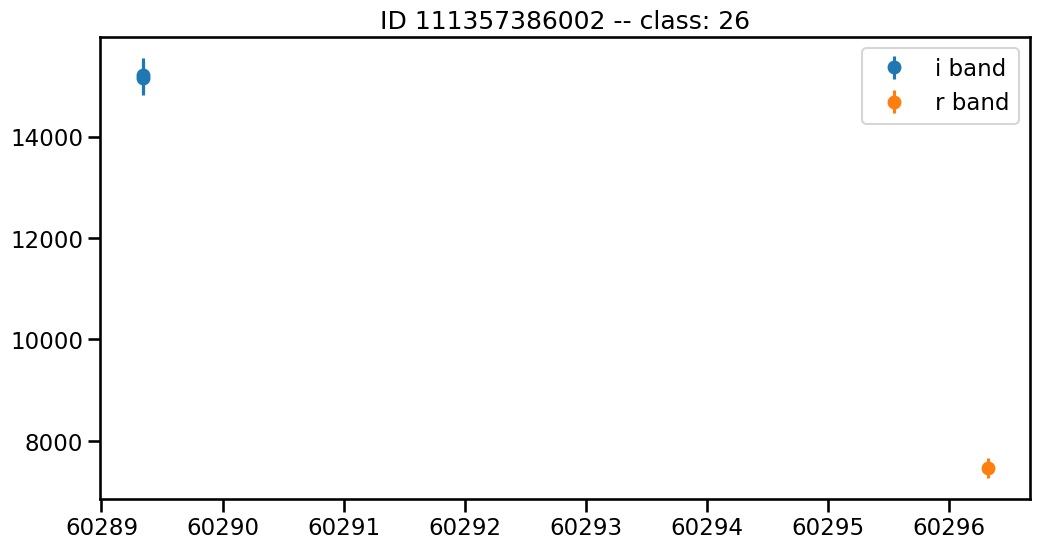

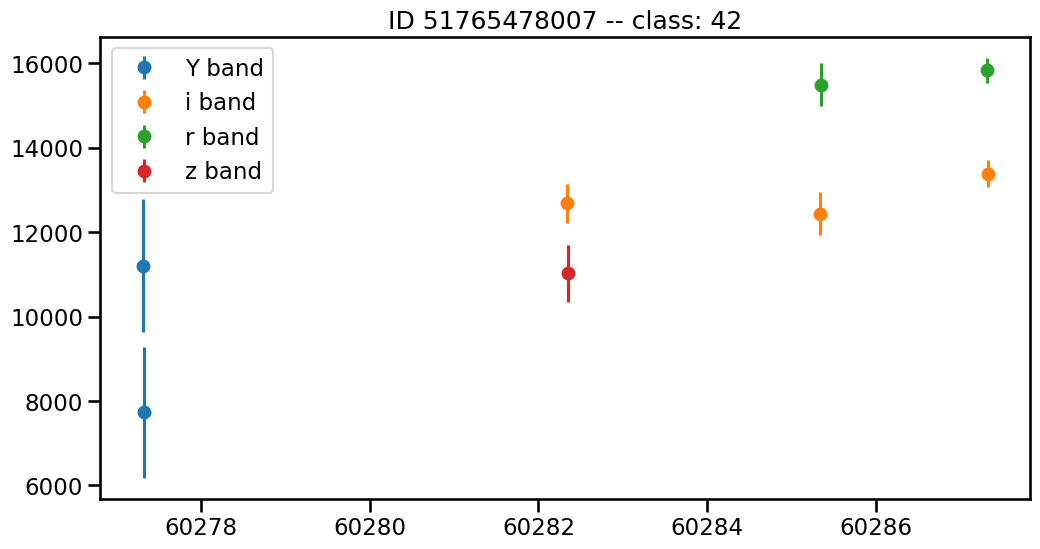

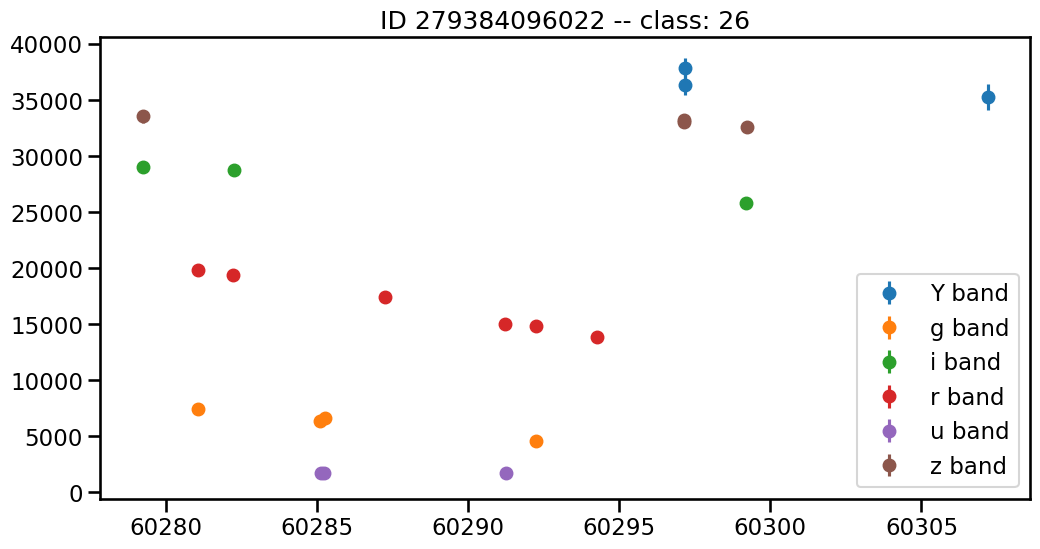

In [11]:
N = 3
seed = np.random.seed(2)
indices = np.random.randint(0, len(sub), N)

for index in indices:
    fig = plt.figure(figsize=(12, 6))
    
    data = sub.iloc[index]
    filters = np.unique(data['cfilterName'])
    
    for filt in filters:
        cond = data['cfilterName'] == filt
        
        plt.errorbar(
            data['cmidPointTai'][cond], 
            data['cpsFlux'][cond], 
            data['cpsFluxErr'][cond],
            ls='',
            marker='o',
            label='{} band'.format(filt)
        )
    plt.title('ID {} -- class: {}'.format(data['alertId'], data['GENTYPE']))
    plt.legend()
    plt.show()

You can find the mapping to the taxonomy at https://github.com/LSSTDESC/elasticc/blob/main/taxonomy/taxonomy.ipynb

## Light curves in magnitudes

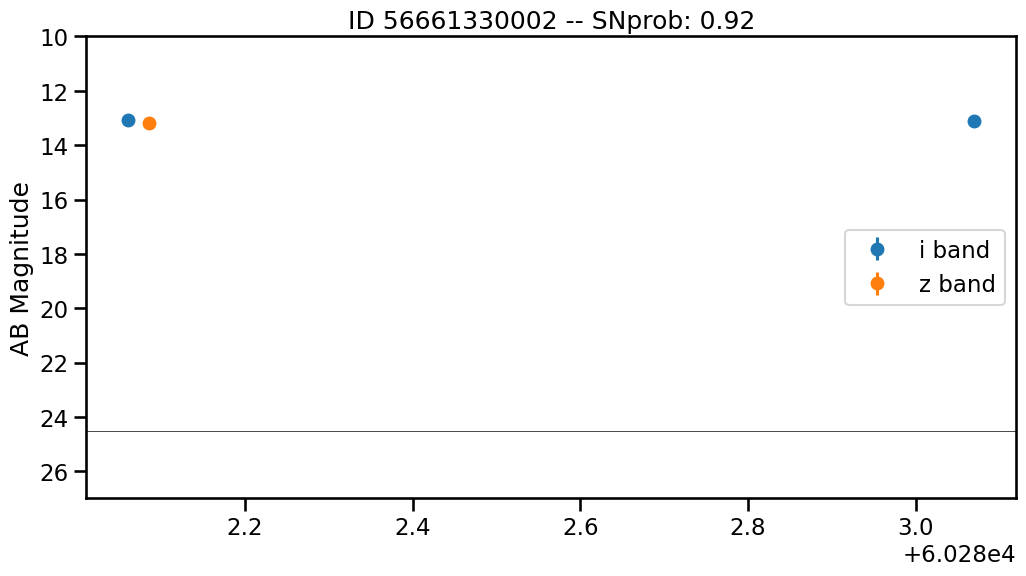

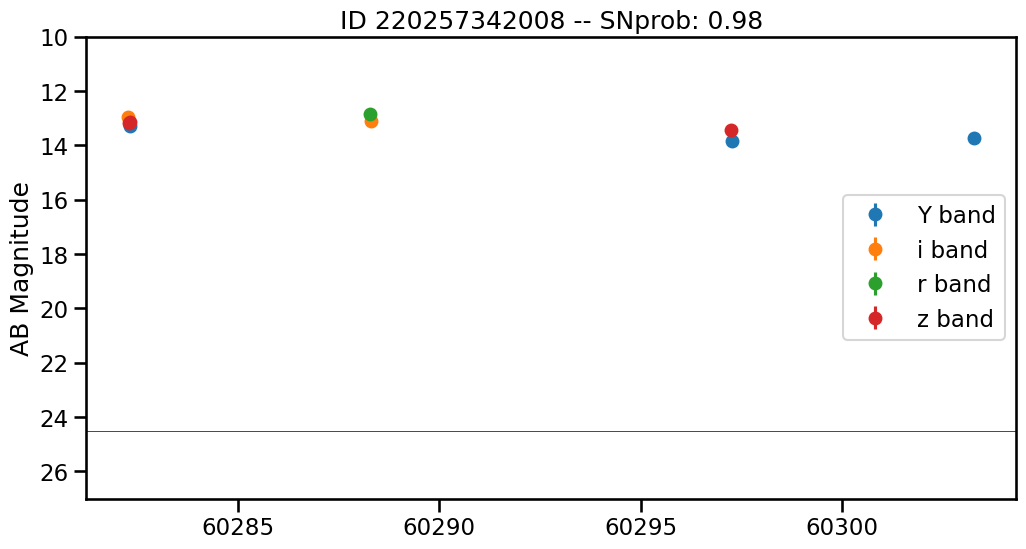

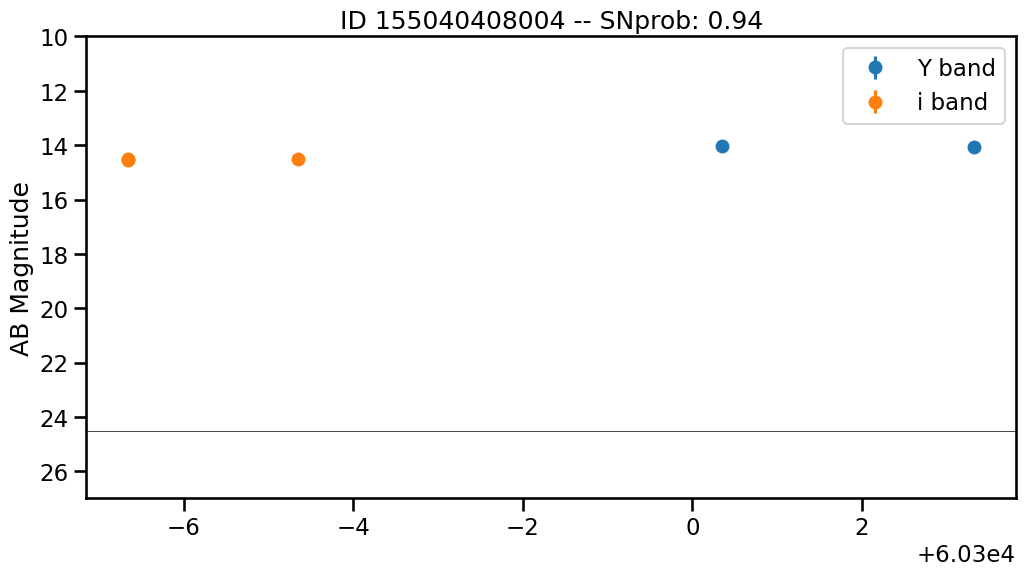

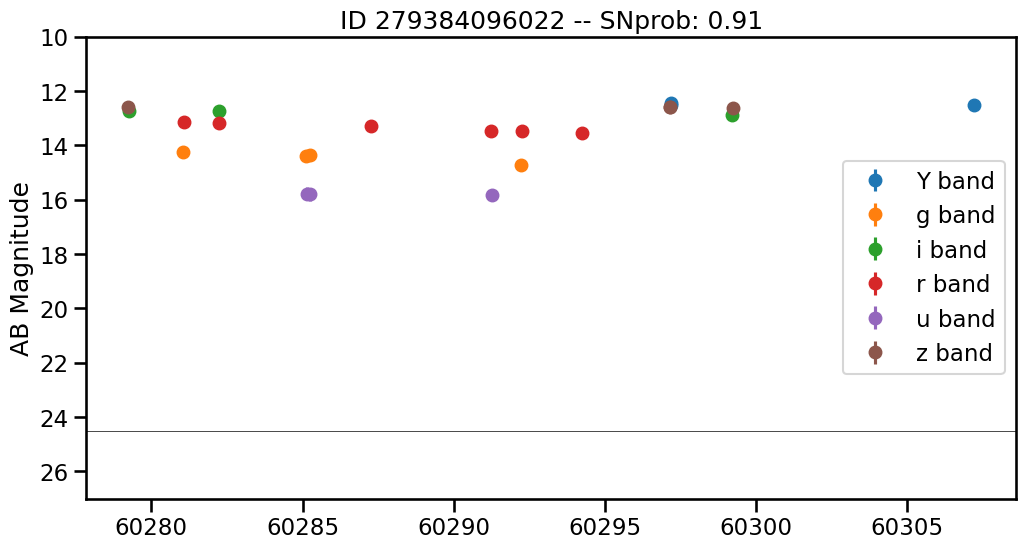

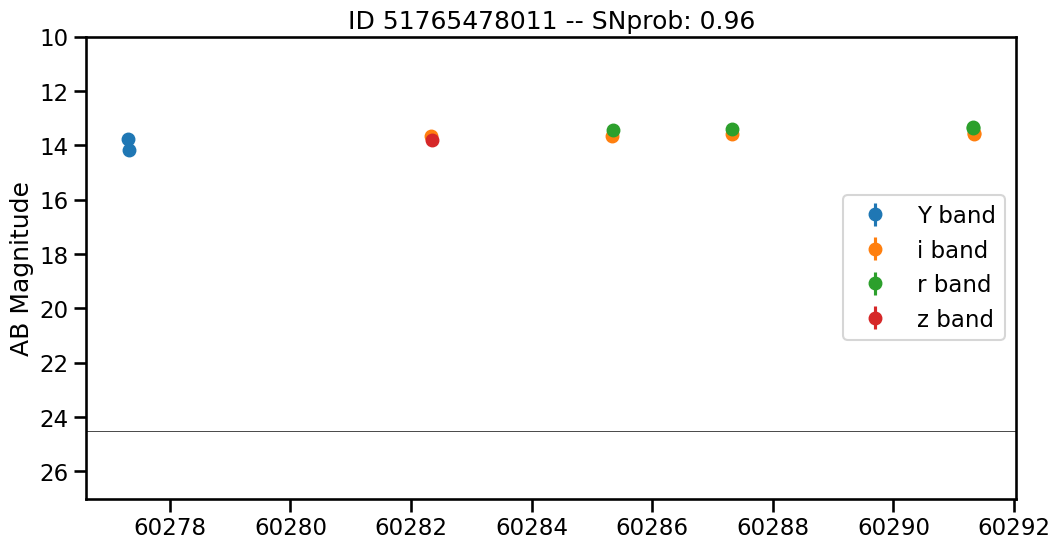

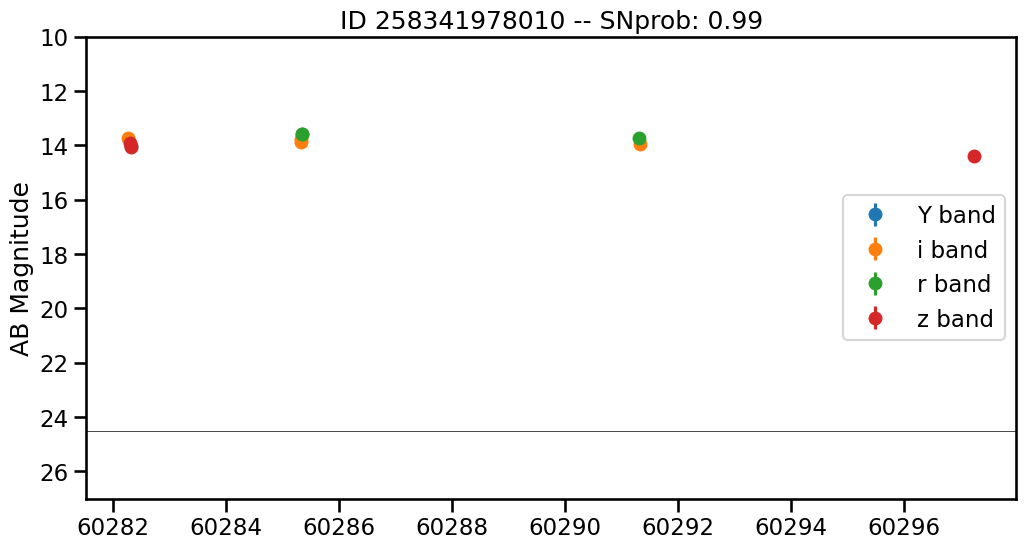

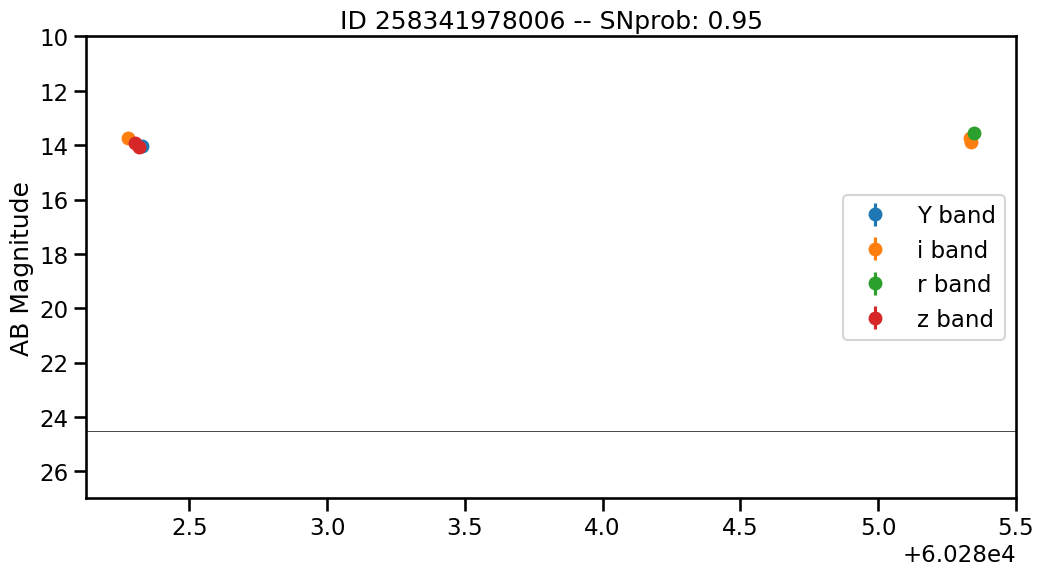

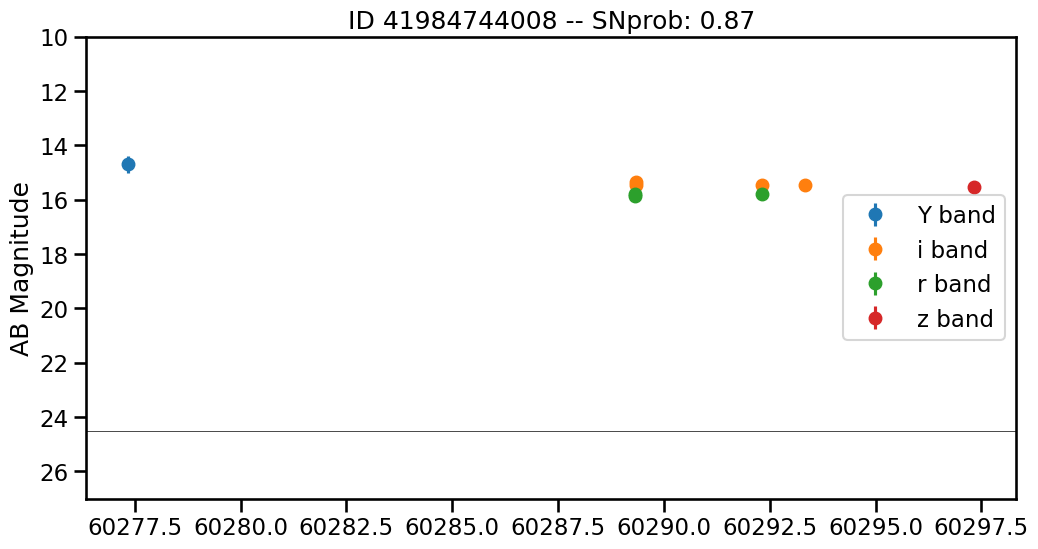

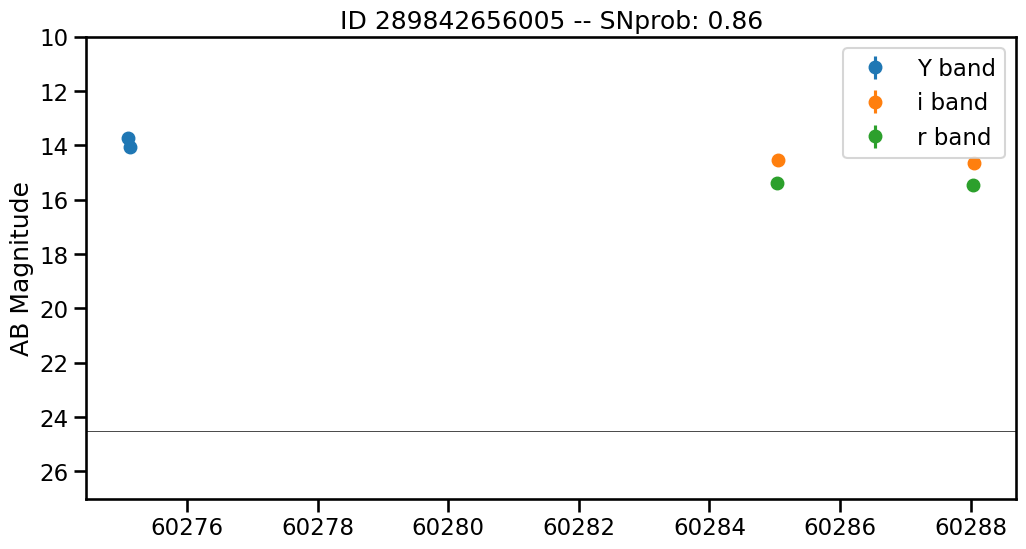

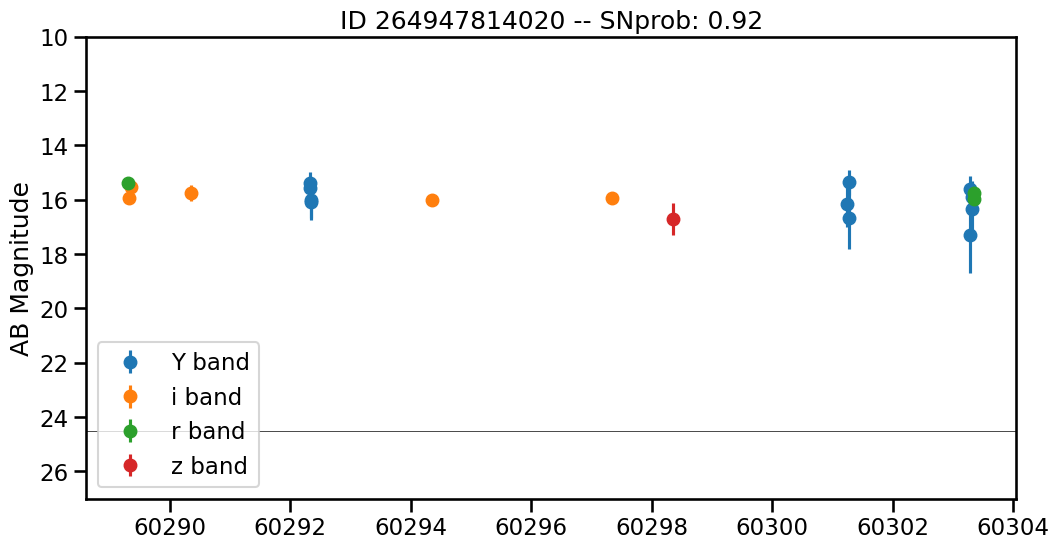

In [12]:
N = 10
seed = np.random.seed(3)
indices = np.random.randint(0, len(sub), N)

for index in indices:
    fig = plt.figure(figsize=(12, 6))
    
    data = sub.iloc[index]
    filters = np.unique(data['cfilterName'])
    
    for filt in filters:
        cond = data['cfilterName'] == filt
        
        plt.errorbar(
            data['cmidPointTai'][cond], 
            data['mags'][cond], 
            data['mags_err'][cond],
            ls='',
            marker='o',
            label='{} band'.format(filt)
        )

    plt.title('ID {} -- SNprob: {:.2f}'.format(data['alertId'], data['snn_snia_vs_nonia']))
    plt.legend()
    plt.ylabel('AB Magnitude')
    plt.gca().invert_yaxis()
    plt.ylim(27, 10)
    plt.axhline(y=24.5, color='black', linewidth=0.5, label='Rubin/LSST nightly limiting magnitude')

    plt.show()

## Adapt light curves analysis to get parameters

In [13]:
# pdf['min_mags'] = pdf['mags'].apply(lambda x: flux_to_mag(x/1000.))
pdf[['mags', 'cfilterName']]

,mags,cfilterName
0,"[13.572754034343419, 13.776973687885814, 14.17...","[i, Y, Y, i, z, i, r, r, i, r, r, i]"
2,"[13.531340445030743, 13.776973687885814, 14.17...","[i, Y, Y, i, z, i, r, r, i, r, r]"
4,"[16.164062540075896, 18.81853613593497, 15.877...","[i, Y, Y, r, i]"
0,"[13.747981878941935, 12.970910125037904, 13.17...","[Y, i, z, z, Y, r, i, z, Y]"
1,"[13.592346026875909, 12.970910125037904, 13.17...","[Y, i, z, z, Y, r, i, z, Y, Y]"
...,...,...
55,"[13.406144519122684, 14.91221439471655, 15.232...","[z, z, z, Y, Y, i, z, g, r, g, r, i, i]"
42,"[14.017935798205947, 14.70967115426965, 14.613...","[Y, z, z, Y, Y, r, i, r, i, i, z, Y, i, z, Y, ..."
43,"[14.200475734500365, 14.70967115426965, 14.613...","[z, z, z, Y, Y, r, i, r, i, i, z, Y, i, z, Y, Y]"
37,"[14.149440468533768, 13.71557582329347, 13.503...","[Y, i, z, g, r, u, g, u, r, u, g, r, u, z, Y]"


In [14]:
# Add a column with the minimum magnitude all bands included
pdf['mags_min_allbands'] = pdf['mags'].apply(min)
pdf[['mags', 'mags_min_allbands']].head()

,mags,mags_min_allbands
0,"[13.572754034343419, 13.776973687885814, 14.17...",13.341533
2,"[13.531340445030743, 13.776973687885814, 14.17...",13.341533
4,"[16.164062540075896, 18.81853613593497, 15.877...",15.868095
0,"[13.747981878941935, 12.970910125037904, 13.17...",12.828574
1,"[13.592346026875909, 12.970910125037904, 13.17...",12.828574


In [15]:
# Add a column with a list of minimum magnitude per band
LSST_FILTERS = ['u', 'g', 'r', 'i', 'z', 'Y']
def get_min_mags(mags: list, filters: str) -> np.array:
    min_mags = []
    for f in LSST_FILTERS:
        # get magnitudes for the current filter
        mask = np.array([int(one==f) for one in filters])
        filter_mags = mask * mags
        # set 0 magnitudes to high values
        filter_mags[filter_mags == 0] = 99
        # get the minimum magnitude, set to nan if no data available
        min_mag = filter_mags.min()
        if min_mag==99:
            min_mag = np.nan
        min_mags.append(min_mag)        
    return np.array(min_mags)

pdf['mags_min'] = pdf[['mags', 'cfilterName']].apply(lambda x: get_min_mags(x.mags, x.cfilterName), axis=1)
pdf[['mags', 'mags_min_allbands', 'mags_min']]

,mags,mags_min_allbands,mags_min
0,"[13.572754034343419, 13.776973687885814, 14.17...",13.341533,"[nan, nan, 13.341533207997692, 13.531340445030..."
2,"[13.531340445030743, 13.776973687885814, 14.17...",13.341533,"[nan, nan, 13.341533207997692, 13.531340445030..."
4,"[16.164062540075896, 18.81853613593497, 15.877...",15.868095,"[nan, nan, 16.16780267190152, 15.8680950193788..."
0,"[13.747981878941935, 12.970910125037904, 13.17...",12.828574,"[nan, nan, 12.828574074407577, 12.970910125037..."
1,"[13.592346026875909, 12.970910125037904, 13.17...",12.828574,"[nan, nan, 12.828574074407577, 12.970910125037..."
...,...,...,...
55,"[13.406144519122684, 14.91221439471655, 15.232...",12.917023,"[nan, 12.982017643382306, 12.917023317817772, ..."
42,"[14.017935798205947, 14.70967115426965, 14.613...",13.703121,"[nan, nan, 13.872701472220278, 13.727079884444..."
43,"[14.200475734500365, 14.70967115426965, 14.613...",13.703121,"[nan, nan, 13.872701472220278, 13.727079884444..."
37,"[14.149440468533768, 13.71557582329347, 13.503...",13.503326,"[17.4496451895483, 14.9800024544083, 13.961084..."


Text(0.5, 1.0, 'Minimum Magnitude')

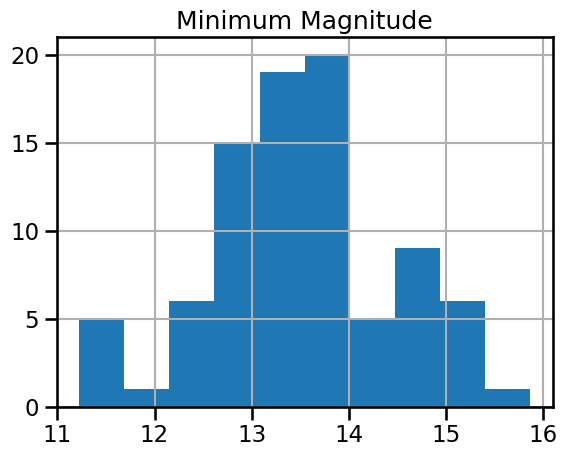

In [16]:
pdf['mags_min_allbands'].hist(bins=10)
plt.title("Minimum Magnitude")

In [19]:
# TODO - compute time of minimum magnitude with respect to first data point

In [17]:
# Not used, just for reference, taken from "power_law_correlations_pseudo_obs.ipynb"
def compute_min_mag_time(df):
    time_max = []
    for i in range(len(lc_open)):
        if lc_open[i]==0:
            time_max.append(np.nan)
        else:
            time_norm = lc_open[i]['time'] - min(lc_open[i]['time'])
            index_max = lc_open[i]['mags'].index(min(lc_open[i]['mags']))
            t_max = time_norm[index_max]

            time_max.append(t_max)
    return time_max

def compute_tmax_t0(df):
    Dt = []
    for i in range(len(lc_open)):    
        mag_u, time_u = [], []
        mag_g, time_g = [], []
        mag_r, time_r = [], []
        mag_i, time_i = [], []
        mag_z, time_z = [], []
        mag_y, time_y = [], []

        if lc_open[i]==0:
            Dt.append(np.nan)
        else:
            for j in range(len(lc_open[i]['mags'])):
                if lc_open[i]['mags'][j] < lc_open[i]['mags_lim'][j]:
                    if lc_open[i]['filt'][j]=='b':
                        mag_u.append(lc_open[i]['mags'][j])
                        time_u.append(lc_open[i]['time'][j])
                    elif lc_open[i]['filt'][j]=='c':
                        mag_g.append(lc_open[i]['mags'][j])
                        time_g.append(lc_open[i]['time'][j])
                    elif lc_open[i]['filt'][j]=='g':
                        mag_r.append(lc_open[i]['mags'][j])
                        time_r.append(lc_open[i]['time'][j])
                    elif lc_open[i]['filt'][j]=='orange':
                        mag_i.append(lc_open[i]['mags'][j])
                        time_i.append(lc_open[i]['time'][j])
                    elif lc_open[i]['filt'][j]=='r':
                        mag_z.append(lc_open[i]['mags'][j])
                        time_z.append(lc_open[i]['time'][j])
                    else:
                        mag_y.append(lc_open[i]['mags'][j])
                        time_y.append(lc_open[i]['time'][j])

            mag_list = [mag_u, mag_g, mag_r, mag_i, mag_z, mag_y]
            time_list = [time_u, time_g, time_r, time_i, time_z, time_y]
            mag_len = [len(i) for i in mag_list]

            mags = mag_list[mag_len.index(max(mag_len))]
            time = time_list[mag_len.index(max(mag_len))]

            if len(mags)!=0:
                Dt.append(time[mags.index(min(mags))] - time[0])
            else:
                Dt.append(np.nan)
    return Dt


def compute_rates(df):
    rate_dec = []
    rate_inc = []
    for i in range(len(lc_open)):
        mag_u, time_u = [], []
        mag_g, time_g = [], []
        mag_r, time_r = [], []
        mag_i, time_i = [], []
        mag_z, time_z = [], []
        mag_y, time_y = [], []
        if lc_open[i]==0:
            rate_dec.append(np.nan)
            rate_inc.append(np.nan)
        else:
            for j in range(len(lc_open[i]['mags'])):
                if lc_open[i]['mags'][j] < lc_open[i]['mags_lim'][j]:
                    if lc_open[i]['filt'][j]=='b':
                        mag_u.append(lc_open[i]['mags'][j])
                        time_u.append(lc_open[i]['time'][j])
                    elif lc_open[i]['filt'][j]=='c':
                        mag_g.append(lc_open[i]['mags'][j])
                        time_g.append(lc_open[i]['time'][j])
                    elif lc_open[i]['filt'][j]=='g':
                        mag_r.append(lc_open[i]['mags'][j])
                        time_r.append(lc_open[i]['time'][j])
                    elif lc_open[i]['filt'][j]=='orange':
                        mag_i.append(lc_open[i]['mags'][j])
                        time_i.append(lc_open[i]['time'][j])
                    elif lc_open[i]['filt'][j]=='r':
                        mag_z.append(lc_open[i]['mags'][j])
                        time_z.append(lc_open[i]['time'][j])
                    else:
                        mag_y.append(lc_open[i]['mags'][j])
                        time_y.append(lc_open[i]['time'][j])

            mag_list = [mag_u, mag_g, mag_r, mag_i, mag_z, mag_y]
            time_list = [time_u, time_g, time_r, time_i, time_z, time_y]
            mag_len = [len(i) for i in mag_list]

            mags = mag_list[mag_len.index(max(mag_len))]
            time = time_list[mag_len.index(max(mag_len))]


            if len(mags)!=0 and mags.index(min(mags))<mags.index(max(mags)):        
                if mags.index(min(mags))==0:
                    index_min = mags.index(min(mags))
                    index_max = mags.index(max(mags))
                    rate_dec.append((mags[index_max] - mags[index_min])/(time[index_max] - time[index_min]))
                    rate_inc.append(np.nan)
                else:
                    index_min = mags.index(min(mags))
                    index_max = mags.index(max(mags))
                    rate_dec.append((mags[index_max] - mags[index_min])/(time[index_max] - time[index_min]))

                    mags2 = mags[0:index_min]
                    index_max2 = mags.index(max(mags2))
                    rate_inc.append((mags[index_min] - mags[index_max2])/(time[index_min] - time[index_max2]))


            elif len(mags)!=0 and mags.index(min(mags))>mags.index(max(mags)):
                if mags.index(min(mags))==(len(mags)-1):
                    index_min = mags.index(min(mags))
                    index_max = mags.index(max(mags))
                    rate_inc.append((mags[index_min] - mags[index_max])/(time[index_min] - time[index_max]))
                    rate_dec.append(np.nan)
                else:
                    index_min = mags.index(min(mags))
                    index_max = mags.index(max(mags))
                    rate_inc.append((mags[index_min] - mags[index_max])/(time[index_min] - time[index_max]))

                    mags2 = mags[index_min:(len(lc_open[i]['mags'])-1)]
                    index_max2 = mags.index(max(mags2))
                    rate_dec.append((mags[index_max2] - mags[index_min])/(time[index_max2] - time[index_min]))
            else:
                rate_inc.append(np.nan)
                rate_dec.append(np.nan)
    return rate_dec, rate_inc

def compute_gr_color(df):
    color = []
    for i in range(len(lc_open)):
        color_inf = []
        color_sup = []
        color_one = []

        mag_u, time_u = [], []
        mag_g, time_g = [], []
        mag_r, time_r = [], []
        mag_i, time_i = [], []
        mag_z, time_z = [], []
        mag_y, time_y = [], []

        if lc_open[i]==0:
            color.append(np.nan)
        else:
            for j in range(len(lc_open[i]['mags'])):
                if lc_open[i]['mags'][j] < lc_open[i]['mags_lim'][j]:
                    if lc_open[i]['filt'][j]=='c':
                        mag_g.append(lc_open[i]['mags'][j])
                        time_g.append(lc_open[i]['time'][j])
                    elif lc_open[i]['filt'][j]=='g':
                        mag_r.append(lc_open[i]['mags'][j])
                        time_r.append(lc_open[i]['time'][j])
            if len(mag_r)!=0 and len(mag_g)!=0:
                for k in range(min(len(mag_r), len(mag_g))):
                    if abs(time_g[k] - time_r[k]) < 0.5:
                        if (mag_g[k] - mag_r[k]) < 0.22:
                            color_inf.append(mag_g[k] - mag_r[k])
                            color_one.append((mag_g[k] - mag_r[k]) + (0.22 - np.mean(color_inf)))
                        else:
                            color_sup.append(mag_g[k] - mag_r[k])
                            color_one.append((mag_g[k] - mag_r[k]) + (0.22 - np.mean(color_sup)))
                color.append(np.mean(color_one))
            else:
                color.append(np.nan)
    return color

